## 1. Environment Setup and Dataset Acquisition

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("master888x/bakery-challenge")

print("Dataset downloaded to:")
print(path)

100%|██████████| 894M/894M [00:09<00:00, 103MB/s] 

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1


## 2. PySpark Initialization


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bakery Demand Forecasting Dissertation") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.3


## 3. Dataset Structure and File Inspection

In [ ]:
import os

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in sorted(files):
        print(os.path.join(root, file))

Dataset path: /root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/01_regions.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/02_cities.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/03_branches.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/04_product_categories.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/05_products.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/06_suppliers.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/07_ingredients.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv/08_product_recipes.csv
/root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/ba

In [ ]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files:", len(csv_files))

for file in sorted(csv_files):
    print(os.path.basename(file))

Total CSV files: 24
01_regions.csv
02_cities.csv
03_branches.csv
04_product_categories.csv
05_products.csv
06_suppliers.csv
07_ingredients.csv
08_product_recipes.csv
09_customers.csv
10_employees.csv
11_employee_shifts.csv
12_orders.csv
13_order_items.csv
14_inventory_stock.csv
15_purchase_orders.csv
16_purchase_order_items.csv
17_promotions.csv
18_customer_feedback.csv
19_daily_production.csv
20_waste_log.csv
21_branch_operating_hours.csv
22_price_history.csv
23_loyalty_transactions.csv
24_equipment.csv


In [ ]:
data_path = os.path.dirname(csv_files[0])
print("CSV folder:", data_path)

CSV folder: /root/.cache/kagglehub/datasets/master888x/bakery-challenge/versions/1/bakery_data_csv


## 4. Loading Core Bakery Datasets

In [ ]:
branches = spark.read.csv(
    f"{data_path}/03_branches.csv",
    header=True,
    inferSchema=True
)

products = spark.read.csv(
    f"{data_path}/05_products.csv",
    header=True,
    inferSchema=True
)

orders = spark.read.csv(
    f"{data_path}/12_orders.csv",
    header=True,
    inferSchema=True
)

order_items = spark.read.csv(
    f"{data_path}/13_order_items.csv",
    header=True,
    inferSchema=True
)

production = spark.read.csv(
    f"{data_path}/19_daily_production.csv",
    header=True,
    inferSchema=True
)

print("Core datasets loaded successfully.")

Core datasets loaded successfully.


## 5. Initial Data Inspection

In [ ]:
print("Branches:", branches.count())
print("Products:", products.count())
print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Daily Production:", production.count())

Branches: 35
Products: 78
Orders: 20004236
Order Items: 50198970
Daily Production: 1037791


In [ ]:
print(" ORDERS SCHEMA ")
orders.printSchema()

print("\n ORDER ITEMS SCHEMA ")
order_items.printSchema()

print("\n DAILY PRODUCTION SCHEMA ")
production.printSchema()

print("\n BRANCHES SCHEMA ")
branches.printSchema()

print("\n PRODUCTS SCHEMA ")
products.printSchema()

 ORDERS SCHEMA 
root
 |-- order_id: integer (nullable = true)
 |-- branch_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- employee_id: integer (nullable = true)
 |-- order_datetime: timestamp (nullable = true)
 |-- order_channel: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- subtotal: double (nullable = true)
 |-- vat_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- loyalty_points_earned: integer (nullable = true)
 |-- notes: string (nullable = true)


 ORDER ITEMS SCHEMA 
root
 |-- order_item_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- discount_amount: double (nullable = true)
 |-- line_total: double (nullable = true)


 DAILY PRODUCTION SCHEMA 
root
 |-- production_id: integer (nullable = true

## 6. Sample Data Examination

In [ ]:
print(" ORDERS ")
orders.show(5, truncate=False)

print(" ORDER ITEMS ")
order_items.show(5, truncate=False)

print(" DAILY PRODUCTION ")
production.show(5, truncate=False)

print(" BRANCHES ")
branches.show(5, truncate=False)

print(" PRODUCTS ")
products.show(5, truncate=False)

 ORDERS 
+--------+---------+-----------+-----------+-------------------+-------------+------------+--------------+--------+----------+------------+---------------------+-----+
|order_id|branch_id|customer_id|employee_id|order_datetime     |order_channel|order_status|payment_method|subtotal|vat_amount|total_amount|loyalty_points_earned|notes|
+--------+---------+-----------+-----------+-------------------+-------------+------------+--------------+--------+----------+------------+---------------------+-----+
|1       |1        |71439      |16         |2019-01-01 07:08:00|Telefoon     |Voltooid    |Contant       |12.8    |1.15      |13.95       |139                  |NULL |
|2       |1        |NULL       |16         |2019-01-01 09:36:00|Winkel       |Voltooid    |PIN           |3.87    |0.35      |4.22        |0                    |NULL |
|3       |1        |132708     |10         |2019-01-01 12:26:00|Winkel       |Voltooid    |PIN           |5.19    |0.47      |5.66        |56          

In [ ]:
from pyspark.sql import functions as F

print(" ORDER DATE RANGE ")
orders.select(
    F.min("order_datetime").alias("first_order"),
    F.max("order_datetime").alias("last_order")
).show(truncate=False)

print(" PRODUCTION DATE RANGE ")
production.select(
    F.min("production_date").alias("first_production"),
    F.max("production_date").alias("last_production")
).show(truncate=False)

 ORDER DATE RANGE 
+-------------------+-------------------+
|first_order        |last_order         |
+-------------------+-------------------+
|2019-01-01 07:00:00|2023-12-31 18:59:00|
+-------------------+-------------------+

 PRODUCTION DATE RANGE 
+----------------+---------------+
|first_production|last_production|
+----------------+---------------+
|2019-01-01      |2023-12-31     |
+----------------+---------------+



## 7. Data Quality Assessment

In [ ]:
orders.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in ["order_id", "branch_id", "order_datetime"]
]).show()

order_items.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in ["order_id", "product_id", "quantity"]
]).show()

production.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in [
        "branch_id",
        "product_id",
        "production_date",
        "planned_quantity",
        "actual_quantity",
        "sold_quantity",
        "wasted_quantity"
    ]
]).show()

+--------+---------+--------------+
|order_id|branch_id|order_datetime|
+--------+---------+--------------+
|       0|        0|             0|
+--------+---------+--------------+

+--------+----------+--------+
|order_id|product_id|quantity|
+--------+----------+--------+
|       0|         0|       0|
+--------+----------+--------+

+---------+----------+---------------+----------------+---------------+-------------+---------------+
|branch_id|product_id|production_date|planned_quantity|actual_quantity|sold_quantity|wasted_quantity|
+---------+----------+---------------+----------------+---------------+-------------+---------------+
|        0|         0|              0|               0|              0|            0|              0|
+---------+----------+---------------+----------------+---------------+-------------+---------------+



In [ ]:
print(
    "Duplicate Order IDs:",
    orders.count() - orders.select("order_id").distinct().count()
)

print(
    "Duplicate Order Item IDs:",
    order_items.count() - order_items.select("order_item_id").distinct().count()
)

print(
    "Duplicate Production IDs:",
    production.count() - production.select("production_id").distinct().count()
)

Duplicate Order IDs: 0
Duplicate Order Item IDs: 0
Duplicate Production IDs: 0


## 8. Construction of Daily Product Demand

In [ ]:
daily_demand = (
    orders
    .select(
        "order_id",
        "branch_id",
        F.to_date("order_datetime").alias("date")
    )
    .join(
        order_items.select("order_id", "product_id", "quantity"),
        on="order_id",
        how="inner"
    )
    .groupBy("branch_id", "product_id", "date")
    .agg(
        F.sum("quantity").alias("daily_demand")
    )
)

print("Daily demand records:", daily_demand.count())
daily_demand.show(10, truncate=False)

Daily demand records: 4575527
+---------+----------+----------+------------+
|branch_id|product_id|date      |daily_demand|
+---------+----------+----------+------------+
|1        |7         |2019-01-01|61          |
|2        |4         |2019-01-01|30          |
|4        |9         |2019-01-01|24          |
|5        |76        |2019-01-01|51          |
|10       |41        |2019-01-01|50          |
|20       |39        |2019-01-01|19          |
|23       |33        |2019-01-01|44          |
|23       |47        |2019-01-01|19          |
|23       |15        |2019-01-01|20          |
|23       |22        |2019-01-01|42          |
+---------+----------+----------+------------+
only showing top 10 rows


## 9. Production and Demand Analysis

In [ ]:
demand_vs_production = (
    production.alias("p")
    .join(
        daily_demand.alias("d"),
        (F.col("p.branch_id") == F.col("d.branch_id")) &
        (F.col("p.product_id") == F.col("d.product_id")) &
        (F.col("p.production_date") == F.col("d.date")),
        "left"
    )
    .select(
        F.col("p.branch_id"),
        F.col("p.product_id"),
        F.col("p.production_date"),
        F.col("p.planned_quantity"),
        F.col("p.actual_quantity"),
        F.col("p.sold_quantity"),
        F.col("p.wasted_quantity"),
        F.col("d.daily_demand")
    )
)

demand_vs_production.show(20, truncate=False)

+---------+----------+---------------+----------------+---------------+-------------+---------------+------------+
|branch_id|product_id|production_date|planned_quantity|actual_quantity|sold_quantity|wasted_quantity|daily_demand|
+---------+----------+---------------+----------------+---------------+-------------+---------------+------------+
|1        |36        |2019-01-01     |23              |25             |24           |1              |35          |
|1        |38        |2019-01-01     |93              |83             |78           |5              |55          |
|1        |42        |2019-01-01     |17              |19             |18           |1              |30          |
|1        |49        |2019-01-01     |88              |82             |78           |4              |46          |
|1        |50        |2019-01-01     |78              |67             |64           |3              |45          |
|1        |73        |2019-01-01     |71              |79             |76       

In [ ]:
comparison = demand_vs_production.filter(
    F.col("daily_demand").isNotNull()
)

comparison.select(
    F.count("*").alias("compared_records"),
    F.sum(
        (F.col("sold_quantity") == F.col("daily_demand"))
        .cast("int")
    ).alias("matching_records")
).show()

comparison.select(
    F.avg(
        F.abs(F.col("sold_quantity") - F.col("daily_demand"))
    ).alias("average_difference")
).show()

+----------------+----------------+
|compared_records|matching_records|
+----------------+----------------+
|         1026470|            8080|
+----------------+----------------+

+------------------+
|average_difference|
+------------------+
|44.123200872894486|
+------------------+



In [ ]:
orders.groupBy("order_status") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(truncate=False)

+--------------+--------+
|order_status  |count   |
+--------------+--------+
|Voltooid      |18403843|
|In Behandeling|600636  |
|Geannuleerd   |599149  |
|Terugbetaald  |400608  |
+--------------+--------+



In [ ]:
daily_demand.select(
    F.avg("daily_demand").alias("avg_demand"),
    F.min("daily_demand").alias("min_demand"),
    F.max("daily_demand").alias("max_demand")
).show()

production.select(
    F.avg("sold_quantity").alias("avg_sold"),
    F.min("sold_quantity").alias("min_sold"),
    F.max("sold_quantity").alias("max_sold")
).show()

+------------------+----------+----------+
|        avg_demand|min_demand|max_demand|
+------------------+----------+----------+
|23.591750633315026|         1|       154|
+------------------+----------+----------+

+-----------------+--------+--------+
|         avg_sold|min_sold|max_sold|
+-----------------+--------+--------+
|62.86389937858394|       4|    1419|
+-----------------+--------+--------+



In [ ]:
completed_orders = orders.filter(
    F.col("order_status") == "Voltooid"
)

completed_daily_demand = (
    completed_orders
    .select(
        "order_id",
        "branch_id",
        F.to_date("order_datetime").alias("date")
    )
    .join(
        order_items.select(
            "order_id",
            "product_id",
            "quantity"
        ),
        on="order_id",
        how="inner"
    )
    .groupBy(
        "branch_id",
        "product_id",
        "date"
    )
    .agg(
        F.sum("quantity").alias("daily_demand")
    )
)

print("Completed daily demand records:",
      completed_daily_demand.count())

completed_daily_demand.select(
    F.avg("daily_demand").alias("avg_demand"),
    F.min("daily_demand").alias("min_demand"),
    F.max("daily_demand").alias("max_demand")
).show()

Completed daily demand records: 4563153
+------------------+----------+----------+
|        avg_demand|min_demand|max_demand|
+------------------+----------+----------+
|21.762143412679784|         1|       147|
+------------------+----------+----------+



In [ ]:
completed_comparison = (
    production.alias("p")
    .join(
        completed_daily_demand.alias("d"),
        (F.col("p.branch_id") == F.col("d.branch_id")) &
        (F.col("p.product_id") == F.col("d.product_id")) &
        (F.col("p.production_date") == F.col("d.date")),
        "inner"
    )
    .select(
        F.col("p.branch_id"),
        F.col("p.product_id"),
        F.col("p.production_date"),
        F.col("p.sold_quantity"),
        F.col("d.daily_demand")
    )
)

completed_comparison.show(10, truncate=False)

+---------+----------+---------------+-------------+------------+
|branch_id|product_id|production_date|sold_quantity|daily_demand|
+---------+----------+---------------+-------------+------------+
|1        |1         |2019-01-21     |40           |29          |
|1        |1         |2019-02-02     |95           |25          |
|1        |1         |2019-03-08     |22           |29          |
|1        |1         |2019-03-15     |57           |28          |
|1        |1         |2019-03-16     |86           |67          |
|1        |1         |2019-03-30     |74           |41          |
|1        |1         |2019-05-11     |88           |87          |
|1        |1         |2019-06-02     |53           |9           |
|1        |1         |2019-06-05     |46           |22          |
|1        |1         |2019-06-12     |12           |46          |
+---------+----------+---------------+-------------+------------+
only showing top 10 rows


In [ ]:
completed_comparison.select(
    F.count("*").alias("records_compared"),

    F.sum(
        (F.col("sold_quantity") == F.col("daily_demand"))
        .cast("int")
    ).alias("exact_matches"),

    (
        F.sum(
            (F.col("sold_quantity") == F.col("daily_demand"))
            .cast("int")
        ) / F.count("*") * 100
    ).alias("exact_match_percentage"),

    F.avg(
        F.abs(
            F.col("sold_quantity") -
            F.col("daily_demand")
        )
    ).alias("mean_absolute_difference")
).show(truncate=False)

+----------------+-------------+----------------------+------------------------+
|records_compared|exact_matches|exact_match_percentage|mean_absolute_difference|
+----------------+-------------+----------------------+------------------------+
|1023703         |7698         |0.7519759148893771    |45.03493493718393       |
+----------------+-------------+----------------------+------------------------+



## 10. Exploratory Data Analysis

In [ ]:
branch_demand = (
    production
    .groupBy("branch_id")
    .agg(
        F.avg("sold_quantity").alias("avg_daily_sold"),
        F.sum("sold_quantity").alias("total_sold")
    )
    .orderBy(F.desc("avg_daily_sold"))
)

branch_demand.show(35, truncate=False)

+---------+------------------+----------+
|branch_id|avg_daily_sold    |total_sold|
+---------+------------------+----------+
|4        |63.43436657681941 |1882732   |
|12       |63.387465550678776|1863021   |
|8        |63.29991552627133 |1873361   |
|13       |63.23027682249992 |1857010   |
|31       |63.17927952147322 |1880089   |
|26       |63.15374214049084 |1868214   |
|30       |63.13064565019703 |1874412   |
|14       |63.08226099845045 |1872660   |
|23       |63.0320152549177  |1884153   |
|18       |63.02371729527693 |1854788   |
|3        |63.01482077591121 |1879291   |
|17       |62.96850526600054 |1865379   |
|29       |62.9495939890158  |1868281   |
|10       |62.94232202126939 |1858435   |
|27       |62.928419775553536|1867275   |
|28       |62.916101837801385|1865777   |
|15       |62.90424348646736 |1866306   |
|20       |62.876485597260455|1872839   |
|6        |62.866367682762345|1864365   |
|19       |62.851755792922226|1841745   |
|5        |62.84620081411126 |1852

In [ ]:
product_demand = (
    production
    .groupBy("product_id")
    .agg(
        F.avg("sold_quantity").alias("avg_daily_sold"),
        F.sum("sold_quantity").alias("total_sold")
    )
    .orderBy(F.desc("total_sold"))
)

product_demand.show(20, truncate=False)

+----------+------------------+----------+
|product_id|avg_daily_sold    |total_sold|
+----------+------------------+----------+
|39        |76.33504226132742 |1101820   |
|69        |76.32055459272097 |1100924   |
|72        |75.68331378905981 |1097181   |
|70        |75.6652031500453  |1085720   |
|30        |75.21810555749738 |1075995   |
|41        |58.780666849615805|856787    |
|51        |59.26543638129596 |854252    |
|2         |58.94898170521229 |853876    |
|63        |58.85672857833322 |852422    |
|21        |58.970614734215815|850887    |
|12        |58.80408022130014 |850307    |
|20        |59.045362973254605|849958    |
|78        |59.33030789639042 |849788    |
|11        |59.25062849162011 |848469    |
|59        |58.739994460601025|848323    |
|53        |58.60968188105117 |847496    |
|28        |58.76830790568655 |847439    |
|29        |59.00633748868306 |847272    |
|32        |58.60917393109174 |847137    |
|57        |58.703223570190644|846794    |
+----------

In [ ]:
weekday_demand = (
    production
    .withColumn(
        "day_of_week",
        F.date_format("production_date", "EEEE")
    )
    .groupBy("day_of_week")
    .agg(
        F.avg("sold_quantity").alias("avg_sold")
    )
    .orderBy(F.desc("avg_sold"))
)

weekday_demand.show(truncate=False)

+-----------+------------------+
|day_of_week|avg_sold          |
+-----------+------------------+
|Saturday   |79.29038664808493 |
|Sunday     |79.23470140915647 |
|Thursday   |56.437296005922136|
|Wednesday  |56.42631363028025 |
|Tuesday    |56.272294424549685|
|Friday     |56.243604176919085|
|Monday     |56.18770345550879 |
+-----------+------------------+



In [ ]:
forecast_df = (
    production
    .select(
        "branch_id",
        "product_id",
        F.col("production_date").alias("date"),
        F.col("sold_quantity").alias("demand")
    )
    .withColumn("day_of_week", F.dayofweek("date"))
    .withColumn("month", F.month("date"))
    .withColumn("year", F.year("date"))
    .withColumn(
        "is_weekend",
        F.when(F.dayofweek("date").isin([1, 7]), 1).otherwise(0)
    )
)

forecast_df.show(10, truncate=False)

+---------+----------+----------+------+-----------+-----+----+----------+
|branch_id|product_id|date      |demand|day_of_week|month|year|is_weekend|
+---------+----------+----------+------+-----------+-----+----+----------+
|1        |73        |2019-01-01|76    |3          |1    |2019|0         |
|1        |42        |2019-01-01|18    |3          |1    |2019|0         |
|1        |41        |2019-01-01|92    |3          |1    |2019|0         |
|1        |17        |2019-01-01|20    |3          |1    |2019|0         |
|1        |21        |2019-01-01|59    |3          |1    |2019|0         |
|1        |49        |2019-01-01|78    |3          |1    |2019|0         |
|1        |74        |2019-01-01|75    |3          |1    |2019|0         |
|1        |36        |2019-01-01|24    |3          |1    |2019|0         |
|1        |29        |2019-01-01|31    |3          |1    |2019|0         |
|1        |68        |2019-01-01|38    |3          |1    |2019|0         |
+---------+----------+---

In [ ]:
from pyspark.sql.window import Window

w = (
    Window
    .partitionBy("branch_id", "product_id")
    .orderBy("date")
)

forecast_df = (
    forecast_df
    .withColumn("lag_1", F.lag("demand", 1).over(w))
    .withColumn("lag_7", F.lag("demand", 7).over(w))
)

forecast_df.select(
    "branch_id",
    "product_id",
    "date",
    "demand",
    "lag_1",
    "lag_7"
).show(20, truncate=False)

+---------+----------+----------+------+-----+-----+
|branch_id|product_id|date      |demand|lag_1|lag_7|
+---------+----------+----------+------+-----+-----+
|1        |1         |2019-01-02|107   |NULL |NULL |
|1        |1         |2019-01-03|79    |107  |NULL |
|1        |1         |2019-01-16|56    |79   |NULL |
|1        |1         |2019-01-17|12    |56   |NULL |
|1        |1         |2019-01-21|40    |12   |NULL |
|1        |1         |2019-01-29|84    |40   |NULL |
|1        |1         |2019-02-01|89    |84   |NULL |
|1        |1         |2019-02-02|95    |89   |107  |
|1        |1         |2019-02-06|14    |95   |79   |
|1        |1         |2019-02-15|84    |14   |56   |
|1        |1         |2019-02-16|88    |84   |12   |
|1        |1         |2019-03-05|34    |88   |40   |
|1        |1         |2019-03-08|22    |34   |84   |
|1        |1         |2019-03-09|123   |22   |89   |
|1        |1         |2019-03-15|57    |123  |95   |
|1        |1         |2019-03-16|86    |57   |

In [ ]:
gap_check = (
    forecast_df
    .withColumn("previous_date", F.lag("date", 1).over(w))
    .withColumn(
        "day_gap",
        F.datediff("date", "previous_date")
    )
)

gap_check.groupBy("day_gap") \
    .count() \
    .orderBy("day_gap") \
    .show(20, truncate=False)

+-------+------+
|day_gap|count |
+-------+------+
|NULL   |2730  |
|1      |233075|
|2      |179602|
|3      |139483|
|4      |108844|
|5      |83962 |
|6      |64935 |
|7      |50390 |
|8      |39016 |
|9      |30412 |
|10     |23485 |
|11     |18180 |
|12     |14192 |
|13     |10968 |
|14     |8311  |
|15     |6682  |
|16     |4962  |
|17     |3947  |
|18     |2994  |
|19     |2396  |
+-------+------+
only showing top 20 rows


## 11. Feature Engineering

In [ ]:
forecast_base = (
    production
    .select(
        "branch_id",
        "product_id",
        F.col("production_date").alias("date"),
        F.col("sold_quantity").alias("demand")
    )
    .withColumn("day_of_week", F.dayofweek("date"))
    .withColumn("month", F.month("date"))
    .withColumn("year", F.year("date"))
    .withColumn(
        "is_weekend",
        F.when(F.dayofweek("date").isin([1, 7]), 1).otherwise(0)
    )
)

forecast_base.show(5)

+---------+----------+----------+------+-----------+-----+----+----------+
|branch_id|product_id|      date|demand|day_of_week|month|year|is_weekend|
+---------+----------+----------+------+-----------+-----+----+----------+
|        1|        73|2019-01-01|    76|          3|    1|2019|         0|
|        1|        42|2019-01-01|    18|          3|    1|2019|         0|
|        1|        41|2019-01-01|    92|          3|    1|2019|         0|
|        1|        17|2019-01-01|    20|          3|    1|2019|         0|
|        1|        21|2019-01-01|    59|          3|    1|2019|         0|
+---------+----------+----------+------+-----------+-----+----+----------+
only showing top 5 rows


In [ ]:
current = forecast_base.alias("c")
past = forecast_base.select(
    F.col("branch_id").alias("p_branch_id"),
    F.col("product_id").alias("p_product_id"),
    F.col("date").alias("p_date"),
    F.col("demand").alias("past_demand")
)

forecast_with_lags = (
    current
    .join(
        past.alias("p1"),
        (F.col("c.branch_id") == F.col("p1.p_branch_id")) &
        (F.col("c.product_id") == F.col("p1.p_product_id")) &
        (F.col("p1.p_date") == F.date_sub(F.col("c.date"), 1)),
        "left"
    )
    .join(
        past.alias("p7"),
        (F.col("c.branch_id") == F.col("p7.p_branch_id")) &
        (F.col("c.product_id") == F.col("p7.p_product_id")) &
        (F.col("p7.p_date") == F.date_sub(F.col("c.date"), 7)),
        "left"
    )
    .select(
        F.col("c.branch_id"),
        F.col("c.product_id"),
        F.col("c.date"),
        F.col("c.demand"),
        F.col("c.day_of_week"),
        F.col("c.month"),
        F.col("c.year"),
        F.col("c.is_weekend"),
        F.col("p1.past_demand").alias("lag_1_day"),
        F.col("p7.past_demand").alias("lag_7_day")
    )
)

forecast_with_lags.show(20, truncate=False)

+---------+----------+----------+------+-----------+-----+----+----------+---------+---------+
|branch_id|product_id|date      |demand|day_of_week|month|year|is_weekend|lag_1_day|lag_7_day|
+---------+----------+----------+------+-----------+-----+----+----------+---------+---------+
|1        |17        |2019-01-01|20    |3          |1    |2019|0         |NULL     |NULL     |
|1        |20        |2019-01-01|34    |3          |1    |2019|0         |NULL     |NULL     |
|1        |25        |2019-01-01|59    |3          |1    |2019|0         |NULL     |NULL     |
|1        |36        |2019-01-01|24    |3          |1    |2019|0         |NULL     |NULL     |
|1        |38        |2019-01-01|78    |3          |1    |2019|0         |NULL     |NULL     |
|1        |40        |2019-01-01|40    |3          |1    |2019|0         |NULL     |NULL     |
|1        |41        |2019-01-01|92    |3          |1    |2019|0         |NULL     |NULL     |
|1        |42        |2019-01-01|18    |3         

In [ ]:
forecast_with_lags.select(
    F.count("*").alias("total_records"),

    F.sum(
        F.col("lag_1_day").isNotNull().cast("int")
    ).alias("records_with_lag_1"),

    F.sum(
        F.col("lag_7_day").isNotNull().cast("int")
    ).alias("records_with_lag_7"),

    F.sum(
        (
            F.col("lag_1_day").isNotNull() &
            F.col("lag_7_day").isNotNull()
        ).cast("int")
    ).alias("records_with_both")
).show()

+-------------+------------------+------------------+-----------------+
|total_records|records_with_lag_1|records_with_lag_7|records_with_both|
+-------------+------------------+------------------+-----------------+
|      1037791|            233075|            231371|            51985|
+-------------+------------------+------------------+-----------------+



In [ ]:
ml_df = (
    forecast_base
    .select(
        "branch_id",
        "product_id",
        "date",
        "day_of_week",
        "month",
        "year",
        "is_weekend",
        "demand"
    )
)

print("ML dataset records:", ml_df.count())

ml_df.show(10, truncate=False)

ML dataset records: 1037791
+---------+----------+----------+-----------+-----+----+----------+------+
|branch_id|product_id|date      |day_of_week|month|year|is_weekend|demand|
+---------+----------+----------+-----------+-----+----+----------+------+
|1        |73        |2019-01-01|3          |1    |2019|0         |76    |
|1        |42        |2019-01-01|3          |1    |2019|0         |18    |
|1        |41        |2019-01-01|3          |1    |2019|0         |92    |
|1        |17        |2019-01-01|3          |1    |2019|0         |20    |
|1        |21        |2019-01-01|3          |1    |2019|0         |59    |
|1        |49        |2019-01-01|3          |1    |2019|0         |78    |
|1        |74        |2019-01-01|3          |1    |2019|0         |75    |
|1        |36        |2019-01-01|3          |1    |2019|0         |24    |
|1        |29        |2019-01-01|3          |1    |2019|0         |31    |
|1        |68        |2019-01-01|3          |1    |2019|0         |38   

## 12. Time-Based Training and Testing Split

In [ ]:
train_df = ml_df.filter(
    F.col("date") < F.lit("2023-01-01")
)

test_df = ml_df.filter(
    F.col("date") >= F.lit("2023-01-01")
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

print("TRAIN DATE RANGE")
train_df.select(
    F.min("date").alias("start"),
    F.max("date").alias("end")
).show()

print("TEST DATE RANGE")
test_df.select(
    F.min("date").alias("start"),
    F.max("date").alias("end")
).show()

Training records: 830460
Testing records: 207331
TRAIN DATE RANGE
+----------+----------+
|     start|       end|
+----------+----------+
|2019-01-01|2022-12-31|
+----------+----------+

TEST DATE RANGE
+----------+----------+
|     start|       end|
+----------+----------+
|2023-01-01|2023-12-31|
+----------+----------+



## 13. Machine Learning Feature Preparation

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "branch_id",
    "product_id",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_ml = assembler.transform(train_df)
test_ml = assembler.transform(test_df)

train_ml.select(
    "date",
    "features",
    "demand"
).show(10, truncate=False)

+----------+-----------------------------+------+
|date      |features                     |demand|
+----------+-----------------------------+------+
|2019-01-01|[1.0,73.0,3.0,1.0,2019.0,0.0]|76    |
|2019-01-01|[1.0,42.0,3.0,1.0,2019.0,0.0]|18    |
|2019-01-01|[1.0,41.0,3.0,1.0,2019.0,0.0]|92    |
|2019-01-01|[1.0,17.0,3.0,1.0,2019.0,0.0]|20    |
|2019-01-01|[1.0,21.0,3.0,1.0,2019.0,0.0]|59    |
|2019-01-01|[1.0,49.0,3.0,1.0,2019.0,0.0]|78    |
|2019-01-01|[1.0,74.0,3.0,1.0,2019.0,0.0]|75    |
|2019-01-01|[1.0,36.0,3.0,1.0,2019.0,0.0]|24    |
|2019-01-01|[1.0,29.0,3.0,1.0,2019.0,0.0]|31    |
|2019-01-01|[1.0,68.0,3.0,1.0,2019.0,0.0]|38    |
+----------+-----------------------------+------+
only showing top 10 rows


## 14. Linear Regression Model

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Train Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="demand",
    predictionCol="prediction"
)

lr_model = lr.fit(train_ml)

# Predict 2023 test data
lr_predictions = lr_model.transform(test_ml)

lr_predictions.select(
    "date",
    "branch_id",
    "product_id",
    "demand",
    "prediction"
).show(10, truncate=False)

+----------+---------+----------+------+-----------------+
|date      |branch_id|product_id|demand|prediction       |
+----------+---------+----------+------+-----------------+
|2023-01-01|1        |4         |44    |68.31203395687207|
|2023-01-01|1        |23        |125   |70.96842160387546|
|2023-01-01|1        |39        |64    |73.20537962240464|
|2023-01-01|1        |77        |118   |78.51815491641142|
|2023-01-01|1        |49        |92    |74.60347838398536|
|2023-01-01|1        |11        |24    |69.29070308997858|
|2023-01-01|1        |17        |70    |70.12956234692702|
|2023-01-01|1        |10        |66    |69.15089321382051|
|2023-01-01|1        |3         |73    |68.172224080714  |
|2023-01-01|1        |18        |63    |70.2693722230851 |
+----------+---------+----------+------+-----------------+
only showing top 10 rows


In [ ]:
rmse_evaluator = RegressionEvaluator(
    labelCol="demand",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="demand",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="demand",
    predictionCol="prediction",
    metricName="r2"
)

lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression Results")
print("RMSE:", lr_rmse)
print("MAE :", lr_mae)
print("R²  :", lr_r2)

Linear Regression Results
RMSE: 44.19089060180107
MAE : 28.400382572451612
R²  : 0.06469937663456704


## 15. Baseline Mean Model

In [ ]:
train_mean = train_df.select(
    F.avg("demand").alias("mean_demand")
).first()["mean_demand"]

baseline_predictions = test_df.withColumn(
    "prediction",
    F.lit(train_mean)
)

baseline_rmse = rmse_evaluator.evaluate(baseline_predictions)
baseline_mae = mae_evaluator.evaluate(baseline_predictions)
baseline_r2 = r2_evaluator.evaluate(baseline_predictions)

print("Baseline Results")
print("Mean demand prediction:", train_mean)
print("RMSE:", baseline_rmse)
print("MAE :", baseline_mae)
print("R²  :", baseline_r2)

Baseline Results
Mean demand prediction: 62.829488476266164
RMSE: 45.694110519210376
MAE : 29.266897311333086
R²  : -1.4209184438840339e-05


In [ ]:
results = [
    ("Baseline Mean", baseline_rmse, baseline_mae, baseline_r2),
    ("Linear Regression", lr_rmse, lr_mae, lr_r2)
]

results_df = spark.createDataFrame(
    results,
    ["Model", "RMSE", "MAE", "R2"]
)

results_df.show(truncate=False)

+-----------------+------------------+------------------+----------------------+
|Model            |RMSE              |MAE               |R2                    |
+-----------------+------------------+------------------+----------------------+
|Baseline Mean    |45.694110519210376|29.266897311333086|-1.4209184438840339E-5|
|Linear Regression|44.19089060180107 |28.400382572451612|0.06469937663456704   |
+-----------------+------------------+------------------+----------------------+



## 16. Random Forest Regression Model

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="demand",
    predictionCol="prediction",
    numTrees=50,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_ml)

rf_predictions = rf_model.transform(test_ml)

rf_predictions.select(
    "date",
    "branch_id",
    "product_id",
    "demand",
    "prediction"
).show(10, truncate=False)

+----------+---------+----------+------+-----------------+
|date      |branch_id|product_id|demand|prediction       |
+----------+---------+----------+------+-----------------+
|2023-01-01|1        |4         |44    |72.98786579113421|
|2023-01-01|1        |23        |125   |74.56238195597672|
|2023-01-01|1        |39        |64    |75.51520150130249|
|2023-01-01|1        |77        |118   |75.71681502389382|
|2023-01-01|1        |49        |92    |75.05579843584948|
|2023-01-01|1        |11        |24    |73.93573261662998|
|2023-01-01|1        |17        |70    |73.12906595521262|
|2023-01-01|1        |10        |66    |73.93573261662998|
|2023-01-01|1        |3         |73    |72.98786579113421|
|2023-01-01|1        |18        |63    |73.12906595521262|
+----------+---------+----------+------+-----------------+
only showing top 10 rows


In [ ]:
rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_mae = mae_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

Random Forest Results
RMSE: 41.656569950434665
MAE : 28.10434709624697
R²  : 0.16890105898189223


In [ ]:
results = [
    ("Baseline Mean", baseline_rmse, baseline_mae, baseline_r2),
    ("Linear Regression", lr_rmse, lr_mae, lr_r2),
    ("Random Forest", rf_rmse, rf_mae, rf_r2)
]

results_df = spark.createDataFrame(
    results,
    ["Model", "RMSE", "MAE", "R2"]
)

results_df.orderBy("RMSE").show(truncate=False)

+-----------------+------------------+------------------+----------------------+
|Model            |RMSE              |MAE               |R2                    |
+-----------------+------------------+------------------+----------------------+
|Random Forest    |41.656569950434665|28.10434709624697 |0.16890105898189223   |
|Linear Regression|44.19089060180107 |28.400382572451612|0.06469937663456704   |
|Baseline Mean    |45.694110519210376|29.266897311333086|-1.4209184438840339E-5|
+-----------------+------------------+------------------+----------------------+



In [ ]:
importances = rf_model.featureImportances

for feature, importance in zip(feature_cols, importances):
    print(feature, ":", float(importance))

branch_id : 0.009534105211555198
product_id : 0.44477456971455887
day_of_week : 0.10693878109690781
month : 0.1776547352826868
year : 0.003995961884559443
is_weekend : 0.2571018468097318


## 17. Gradient Boosted Trees Model

In [ ]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="demand",
    predictionCol="prediction",
    maxIter=50,
    maxDepth=8,
    stepSize=0.1,
    seed=42
)

gbt_model = gbt.fit(train_ml)

gbt_predictions = gbt_model.transform(test_ml)

gbt_predictions.select(
    "date",
    "branch_id",
    "product_id",
    "demand",
    "prediction"
).show(10, truncate=False)

+----------+---------+----------+------+-----------------+
|date      |branch_id|product_id|demand|prediction       |
+----------+---------+----------+------+-----------------+
|2023-01-01|1        |4         |44    |77.35967535519933|
|2023-01-01|1        |23        |125   |76.6988384275707 |
|2023-01-01|1        |39        |64    |76.3558287358176 |
|2023-01-01|1        |77        |118   |76.10341160371613|
|2023-01-01|1        |49        |92    |73.37800689655755|
|2023-01-01|1        |11        |24    |75.6893286548964 |
|2023-01-01|1        |17        |70    |71.93885291632883|
|2023-01-01|1        |10        |66    |75.6893286548964 |
|2023-01-01|1        |3         |73    |77.35967535519933|
|2023-01-01|1        |18        |63    |71.93885291632883|
+----------+---------+----------+------+-----------------+
only showing top 10 rows


In [ ]:
gbt_rmse = rmse_evaluator.evaluate(gbt_predictions)
gbt_mae = mae_evaluator.evaluate(gbt_predictions)
gbt_r2 = r2_evaluator.evaluate(gbt_predictions)

print("Gradient Boosted Trees Results")
print("RMSE:", gbt_rmse)
print("MAE :", gbt_mae)
print("R²  :", gbt_r2)

Gradient Boosted Trees Results
RMSE: 40.49080455916596
MAE : 28.251850254810716
R²  : 0.21476702669828418


## 18. Model Performance Comparison

In [ ]:
results = [
    ("Baseline Mean", baseline_rmse, baseline_mae, baseline_r2),
    ("Linear Regression", lr_rmse, lr_mae, lr_r2),
    ("Random Forest", rf_rmse, rf_mae, rf_r2),
    ("Gradient Boosted Trees", gbt_rmse, gbt_mae, gbt_r2)
]

final_results_df = spark.createDataFrame(
    results,
    ["Model", "RMSE", "MAE", "R2"]
)

final_results_df.orderBy("RMSE").show(truncate=False)

+----------------------+------------------+------------------+----------------------+
|Model                 |RMSE              |MAE               |R2                    |
+----------------------+------------------+------------------+----------------------+
|Gradient Boosted Trees|40.49080455916596 |28.251850254810716|0.21476702669828418   |
|Random Forest         |41.656569950434665|28.10434709624697 |0.16890105898189223   |
|Linear Regression     |44.19089060180107 |28.400382572451612|0.06469937663456704   |
|Baseline Mean         |45.694110519210376|29.266897311333086|-1.4209184438840339E-5|
+----------------------+------------------+------------------+----------------------+



## 19. GBT Feature Importance Analysis

In [ ]:
gbt_importances = gbt_model.featureImportances

for feature, importance in zip(feature_cols, gbt_importances):
    print(feature, ":", float(importance))

branch_id : 0.06768407538889243
product_id : 0.4548386089863854
day_of_week : 0.0449466994187708
month : 0.21419892146495573
year : 0.03916735627927717
is_weekend : 0.17916433846171842


## 20. Prediction Error Analysis

In [ ]:
from pyspark.sql import functions as F

gbt_error_analysis = (
    gbt_predictions
    .select(
        "date",
        "branch_id",
        "product_id",
        "demand",
        "prediction"
    )
    .withColumn(
        "absolute_error",
        F.abs(F.col("demand") - F.col("prediction"))
    )
)

gbt_error_analysis.orderBy(
    F.desc("absolute_error")
).show(20, truncate=False)

+----------+---------+----------+------+------------------+-----------------+
|date      |branch_id|product_id|demand|prediction        |absolute_error   |
+----------+---------+----------+------+------------------+-----------------+
|2023-04-30|11       |43        |1419  |199.16773118846012|1219.83226881154 |
|2023-04-29|15       |43        |1221  |228.98342559620255|992.0165744037974|
|2023-04-30|28       |43        |1121  |195.06739447594526|925.9326055240547|
|2023-04-30|2        |43        |1068  |199.21952988264385|868.7804701173561|
|2023-04-29|28       |43        |1054  |203.77657620434522|850.2234237956548|
|2023-04-23|6        |43        |1042  |198.23527121635607|843.7647287836439|
|2023-04-24|6        |43        |1005  |177.58101699609387|827.4189830039061|
|2023-04-22|25       |43        |1015  |207.3342909799733 |807.6657090200267|
|2023-04-20|19       |43        |956   |176.4691530101557 |779.5308469898443|
|2023-04-24|20       |43        |943   |173.13413844043305|769.8

In [ ]:
product_error = (
    gbt_error_analysis
    .groupBy("product_id")
    .agg(
        F.count("*").alias("records"),
        F.avg("absolute_error").alias("avg_absolute_error"),
        F.max("absolute_error").alias("max_absolute_error")
    )
    .orderBy(F.desc("avg_absolute_error"))
)

product_error.show(20, truncate=False)

+----------+-------+------------------+------------------+
|product_id|records|avg_absolute_error|max_absolute_error|
+----------+-------+------------------+------------------+
|43        |207    |220.0639556111595 |1219.83226881154  |
|61        |525    |147.59924656406847|571.5585249213734 |
|56        |479    |136.0838390597763 |742.4647807593917 |
|55        |502    |132.86394884112156|715.8208413149139 |
|68        |716    |120.72017856574904|584.9873671902674 |
|45        |702    |93.6129786728915  |465.68411766818485|
|44        |731    |91.31032528046381 |524.8786204725532 |
|42        |2843   |54.430272630364996|321.3892390254864 |
|69        |2874   |38.70969128058201 |201.56981118185223|
|54        |2913   |37.53375015363998 |203.4479097402213 |
|53        |2899   |37.2353076653262  |165.8121722949874 |
|67        |2846   |35.35900709416421 |205.27369156072012|
|30        |2830   |34.44912130524725 |175.26729154920008|
|72        |2837   |32.94895624599975 |120.3012057170845

In [ ]:
branch_prediction_summary = (
    gbt_predictions
    .groupBy("branch_id")
    .agg(
        F.avg("demand").alias("avg_actual_demand"),
        F.avg("prediction").alias("avg_predicted_demand"),
        F.avg(
            F.abs(F.col("demand") - F.col("prediction"))
        ).alias("avg_absolute_error")
    )
    .orderBy(F.desc("avg_actual_demand"))
)

branch_prediction_summary.show(35, truncate=False)

+---------+------------------+--------------------+------------------+
|branch_id|avg_actual_demand |avg_predicted_demand|avg_absolute_error|
+---------+------------------+--------------------+------------------+
|12       |64.3166231505657  |63.62846722940314   |28.661357550096284|
|17       |63.86770494608934 |62.695939617668     |28.414821406041426|
|31       |63.71912550066756 |63.31433795908657   |29.40025419851589 |
|13       |63.65559116208467 |63.603232308401964  |28.09078912992285 |
|35       |63.51732755748084 |62.997622688098396  |28.813201529342603|
|8        |63.49279920542956 |63.013687238527815  |28.757022031974877|
|5        |63.45565648224608 |63.324171305029886  |28.499941038081225|
|15       |63.43525480367585 |63.2489632455275    |28.76375647507239 |
|28       |63.36236236236236 |62.61239231340992   |28.44894173303241 |
|10       |63.292380286613074|62.53204108531914   |27.959546526949577|
|32       |63.291695030633086|62.81033931484276   |28.487966599814982|
|16   

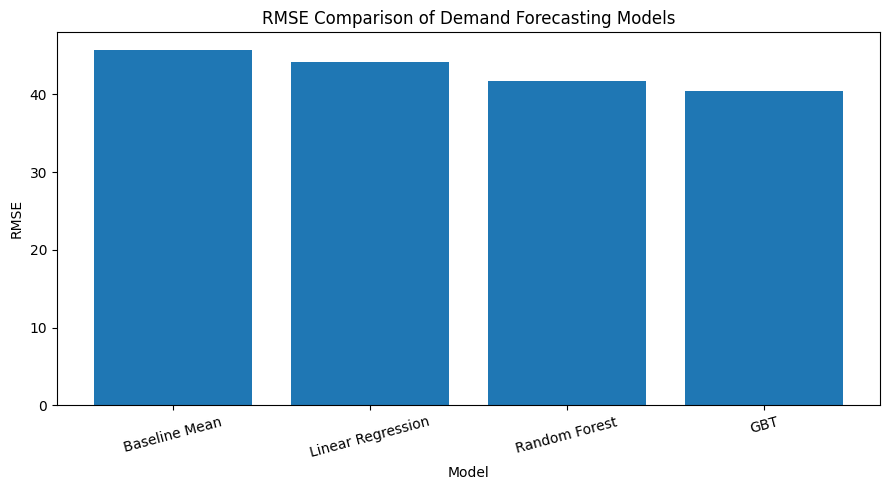

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Baseline Mean",
    "Linear Regression",
    "Random Forest",
    "GBT"
]

rmse_values = [
    baseline_rmse,
    lr_rmse,
    rf_rmse,
    gbt_rmse
]

plt.figure(figsize=(9, 5))
plt.bar(models, rmse_values)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Demand Forecasting Models")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
final_predictions = (
    gbt_predictions
    .select(
        "date",
        "branch_id",
        "product_id",
        F.col("demand").alias("actual_demand"),
        F.round("prediction", 2).alias("predicted_demand")
    )
    .withColumn(
        "absolute_error",
        F.round(
            F.abs(F.col("actual_demand") - F.col("predicted_demand")),
            2
        )
    )
    .orderBy("date", "branch_id", "product_id")
)

print("FINAL GBT PREDICTION SAMPLE")
final_predictions.show(20, truncate=False)

FINAL GBT PREDICTION SAMPLE
+----------+---------+----------+-------------+----------------+--------------+
|date      |branch_id|product_id|actual_demand|predicted_demand|absolute_error|
+----------+---------+----------+-------------+----------------+--------------+
|2023-01-01|1        |3         |73           |77.36           |4.36          |
|2023-01-01|1        |4         |44           |77.36           |33.36         |
|2023-01-01|1        |10        |66           |75.69           |9.69          |
|2023-01-01|1        |11        |24           |75.69           |51.69         |
|2023-01-01|1        |13        |89           |70.87           |18.13         |
|2023-01-01|1        |14        |61           |70.87           |9.87          |
|2023-01-01|1        |17        |70           |71.94           |1.94          |
|2023-01-01|1        |18        |63           |71.94           |8.94          |
|2023-01-01|1        |21        |85           |76.31           |8.69          |
|2023-01-01|

In [ ]:
final_model_comparison = spark.createDataFrame(
    [
        ("Baseline Mean", baseline_rmse, baseline_mae, baseline_r2),
        ("Linear Regression", lr_rmse, lr_mae, lr_r2),
        ("Random Forest", rf_rmse, rf_mae, rf_r2),
        ("Gradient Boosted Trees", gbt_rmse, gbt_mae, gbt_r2)
    ],
    ["Model", "RMSE", "MAE", "R2"]
)

final_model_comparison = (
    final_model_comparison
    .select(
        "Model",
        F.round("RMSE", 3).alias("RMSE"),
        F.round("MAE", 3).alias("MAE"),
        F.round("R2", 3).alias("R2")
    )
    .orderBy("RMSE")
)

print("FINAL MODEL PERFORMANCE COMPARISON")
final_model_comparison.show(truncate=False)

FINAL MODEL PERFORMANCE COMPARISON
+----------------------+------+------+-----+
|Model                 |RMSE  |MAE   |R2   |
+----------------------+------+------+-----+
|Gradient Boosted Trees|40.491|28.252|0.215|
|Random Forest         |41.657|28.104|0.169|
|Linear Regression     |44.191|28.4  |0.065|
|Baseline Mean         |45.694|29.267|0.0  |
+----------------------+------+------+-----+



In [ ]:
gbt_rmse_improvement = (
    (baseline_rmse - gbt_rmse) / baseline_rmse
) * 100

gbt_mae_improvement = (
    (baseline_mae - gbt_mae) / baseline_mae
) * 100

rf_rmse_improvement = (
    (baseline_rmse - rf_rmse) / baseline_rmse
) * 100

lr_rmse_improvement = (
    (baseline_rmse - lr_rmse) / baseline_rmse
) * 100


print("MODEL IMPROVEMENT OVER BASELINE")
print("--------------------------------")
print(f"Linear Regression RMSE improvement: {lr_rmse_improvement:.2f}%")
print(f"Random Forest RMSE improvement:      {rf_rmse_improvement:.2f}%")
print(f"GBT RMSE improvement:                {gbt_rmse_improvement:.2f}%")
print(f"GBT MAE improvement:                 {gbt_mae_improvement:.2f}%")

MODEL IMPROVEMENT OVER BASELINE
--------------------------------
Linear Regression RMSE improvement: 3.29%
Random Forest RMSE improvement:      8.84%
GBT RMSE improvement:                11.39%
GBT MAE improvement:                 3.47%


## 21. Actual vs Predicted Demand

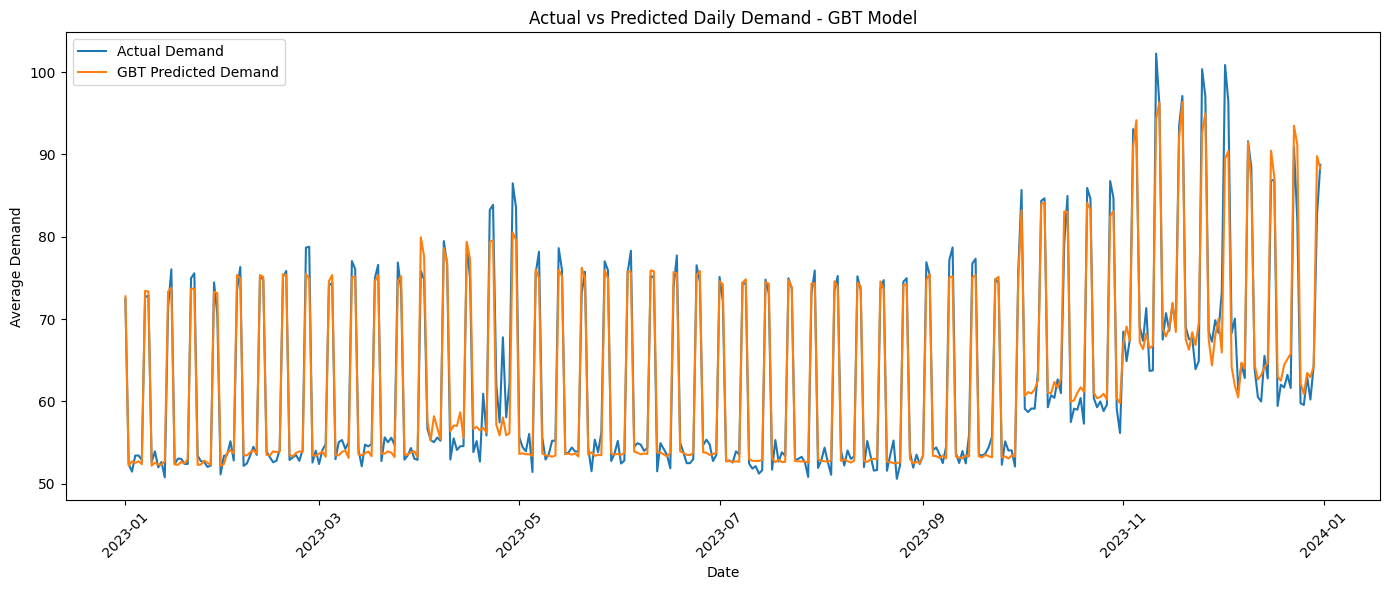

In [ ]:
daily_prediction = (
    gbt_predictions
    .groupBy("date")
    .agg(
        F.avg("demand").alias("actual_demand"),
        F.avg("prediction").alias("predicted_demand")
    )
    .orderBy("date")
)

daily_plot = daily_prediction.toPandas()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_plot["date"],
    daily_plot["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    daily_plot["date"],
    daily_plot["predicted_demand"],
    label="GBT Predicted Demand"
)

plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.title("Actual vs Predicted Daily Demand - GBT Model")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

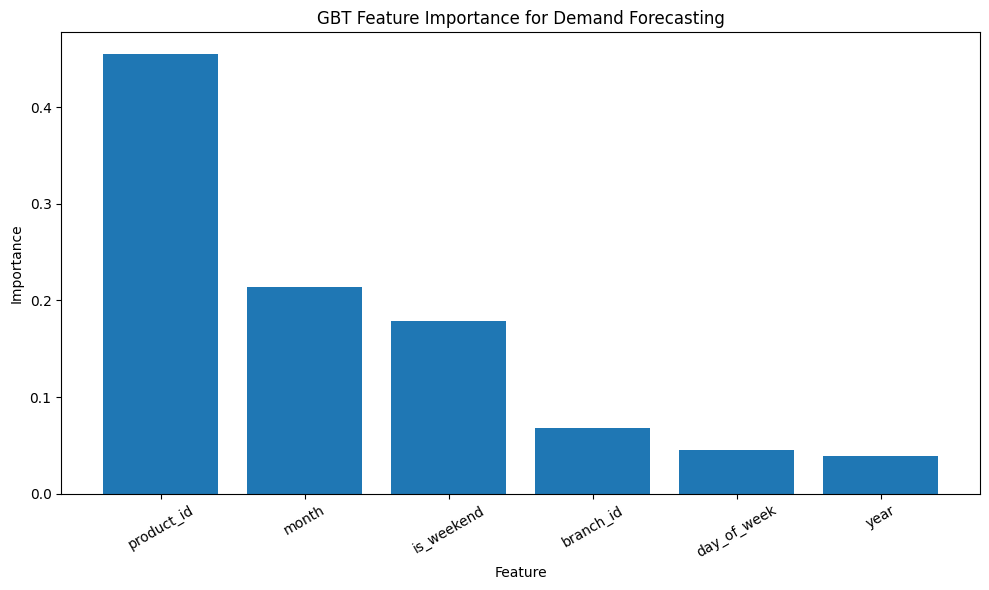

In [ ]:
g_importance_values = [
    float(x) for x in gbt_model.featureImportances
]

feature_importance_data = list(
    zip(feature_cols, g_importance_values)
)

feature_importance_data = sorted(
    feature_importance_data,
    key=lambda x: x[1],
    reverse=True
)

feature_names = [x[0] for x in feature_importance_data]
importance_values = [x[1] for x in feature_importance_data]

plt.figure(figsize=(10, 6))

plt.bar(
    feature_names,
    importance_values
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("GBT Feature Importance for Demand Forecasting")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

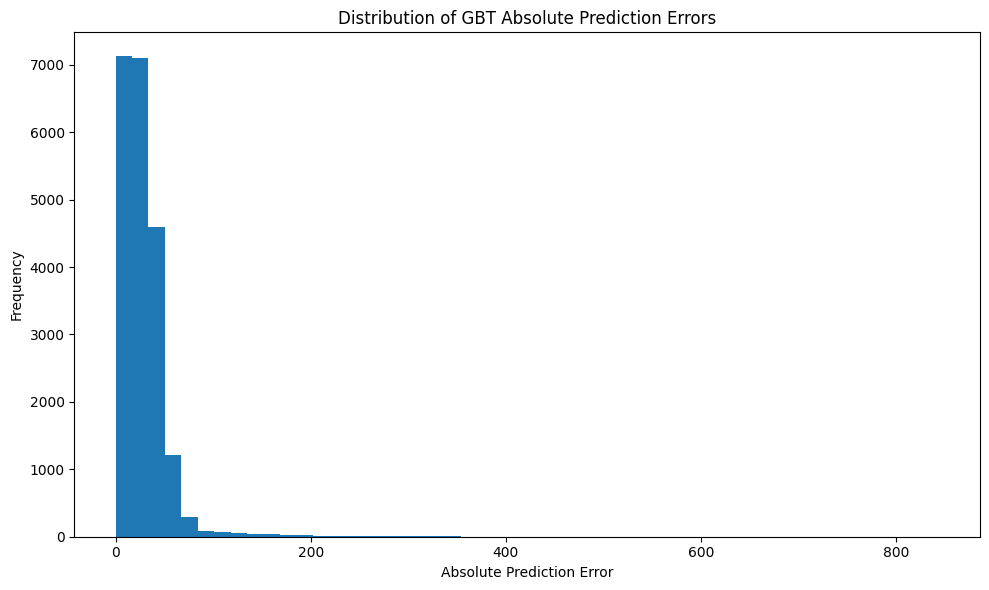

In [ ]:
error_sample = (
    gbt_error_analysis
    .select("absolute_error")
    .sample(False, 0.1, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.hist(
    error_sample["absolute_error"],
    bins=50
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of GBT Absolute Prediction Errors")

plt.tight_layout()
plt.show()

In [ ]:
error_percentiles = gbt_error_analysis.approxQuantile(
    "absolute_error",
    [0.50, 0.75, 0.90, 0.95, 0.99],
    0.001
)

percentile_names = ["50th", "75th", "90th", "95th", "99th"]

print("GBT ABSOLUTE ERROR PERCENTILES")
print("--------------------------------")

for name, value in zip(percentile_names, error_percentiles):
    print(f"{name} percentile: {value:.2f}")

GBT ABSOLUTE ERROR PERCENTILES
--------------------------------
50th percentile: 24.52
75th percentile: 37.53
90th percentile: 49.60
95th percentile: 59.52
99th percentile: 130.40


## 22. Detailed Forecasting Error Analysis

In [ ]:
demand_level_error = (
    gbt_error_analysis
    .withColumn(
        "demand_level",
        F.when(F.col("demand") < 50, "Low (<50)")
         .when(F.col("demand") < 100, "Medium (50-99)")
         .otherwise("High (100+)")
    )
    .groupBy("demand_level")
    .agg(
        F.count("*").alias("records"),
        F.round(F.avg("demand"), 2).alias("avg_demand"),
        F.round(F.avg("absolute_error"), 2).alias("avg_absolute_error"),
        F.round(F.max("absolute_error"), 2).alias("max_absolute_error")
    )
)

demand_level_error.show(truncate=False)

+--------------+-------+----------+------------------+------------------+
|demand_level  |records|avg_demand|avg_absolute_error|max_absolute_error|
+--------------+-------+----------+------------------+------------------+
|Low (<50)     |84993  |29.58     |29.86             |321.39            |
|High (100+)   |25021  |139.05    |59.24             |1219.83           |
|Medium (50-99)|97317  |72.64     |18.88             |273.39            |
+--------------+-------+----------+------------------+------------------+



In [ ]:
weekend_error = (
    gbt_predictions
    .withColumn(
        "absolute_error",
        F.abs(F.col("demand") - F.col("prediction"))
    )
    .withColumn(
        "day_type",
        F.when(F.col("is_weekend") == 1, "Weekend")
         .otherwise("Weekday")
    )
    .groupBy("day_type")
    .agg(
        F.count("*").alias("records"),
        F.round(F.avg("demand"), 2).alias("avg_actual_demand"),
        F.round(F.avg("prediction"), 2).alias("avg_predicted_demand"),
        F.round(F.avg("absolute_error"), 2).alias("avg_absolute_error"),
        F.round(F.max("absolute_error"), 2).alias("max_absolute_error")
    )
)

weekend_error.show(truncate=False)

+--------+-------+-----------------+--------------------+------------------+------------------+
|day_type|records|avg_actual_demand|avg_predicted_demand|avg_absolute_error|max_absolute_error|
+--------+-------+-----------------+--------------------+------------------+------------------+
|Weekday |147539 |56.3             |56.32               |25.15             |827.42            |
|Weekend |59792  |79.55            |78.93               |35.91             |1219.83           |
+--------+-------+-----------------+--------------------+------------------+------------------+



In [ ]:
monthly_error = (
    gbt_predictions
    .withColumn("month_num", F.month("date"))
    .withColumn(
        "absolute_error",
        F.abs(F.col("demand") - F.col("prediction"))
    )
    .groupBy("month_num")
    .agg(
        F.count("*").alias("records"),
        F.round(F.avg("demand"), 2).alias("avg_actual_demand"),
        F.round(F.avg("prediction"), 2).alias("avg_predicted_demand"),
        F.round(F.avg("absolute_error"), 2).alias("avg_absolute_error")
    )
    .orderBy("month_num")
)

monthly_error.show(12, truncate=False)

+---------+-------+-----------------+--------------------+------------------+
|month_num|records|avg_actual_demand|avg_predicted_demand|avg_absolute_error|
+---------+-------+-----------------+--------------------+------------------+
|1        |18032  |58.64            |58.55               |25.12             |
|2        |15513  |59.79            |59.8                |25.29             |
|3        |17212  |59.7             |59.23               |25.15             |
|4        |17082  |64.49            |64.17               |29.51             |
|5        |17312  |59.86            |59.17               |24.95             |
|6        |16673  |59.59            |59.53               |25.15             |
|7        |17312  |59.58            |59.73               |25.31             |
|8        |17470  |58.48            |58.3                |24.55             |
|9        |16808  |60.63            |59.91               |25.58             |
|10       |17893  |66.87            |67.59               |32.22 

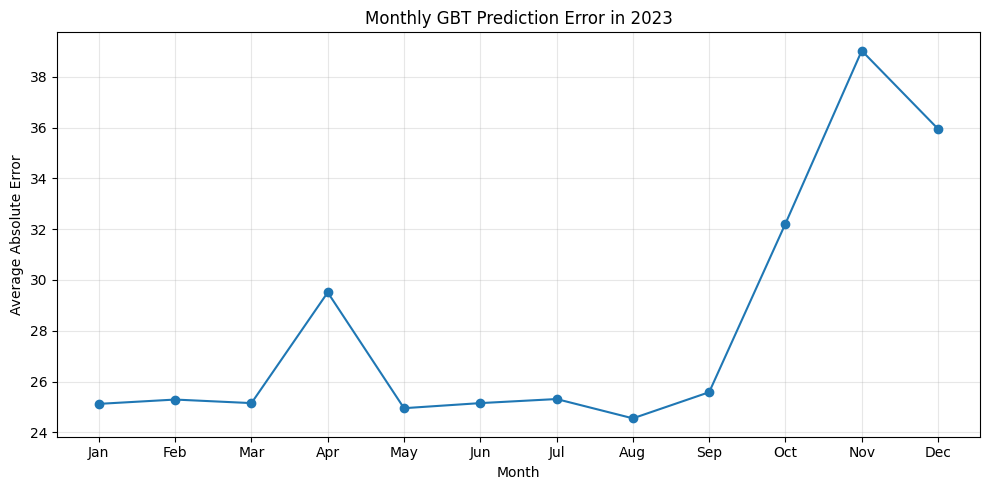

In [ ]:
monthly_plot = monthly_error.toPandas()

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    month_names,
    monthly_plot["avg_absolute_error"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Absolute Error")
plt.title("Monthly GBT Prediction Error in 2023")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 23. Overall Prediction Bias

In [ ]:
prediction_bias = (
    gbt_predictions
    .select(
        F.avg("demand").alias("avg_actual"),
        F.avg("prediction").alias("avg_predicted"),
        F.avg(
            F.col("prediction") - F.col("demand")
        ).alias("mean_bias")
    )
    .first()
)

avg_actual = prediction_bias["avg_actual"]
avg_predicted = prediction_bias["avg_predicted"]
mean_bias = prediction_bias["mean_bias"]

print("GBT OVERALL PREDICTION BIAS")
print("---------------------------")
print(f"Average actual demand:    {avg_actual:.2f}")
print(f"Average predicted demand: {avg_predicted:.2f}")
print(f"Mean prediction bias:     {mean_bias:.2f}")

if mean_bias > 0:
    print("Interpretation: Model slightly OVER-PREDICTS demand.")
elif mean_bias < 0:
    print("Interpretation: Model slightly UNDER-PREDICTS demand.")
else:
    print("Interpretation: No overall prediction bias.")

GBT OVERALL PREDICTION BIAS
---------------------------
Average actual demand:    63.00
Average predicted demand: 62.84
Mean prediction bias:     -0.16
Interpretation: Model slightly UNDER-PREDICTS demand.


## 24. Final Results Summary

In [ ]:
print("=" * 55)
print("FINAL DEMAND FORECASTING ANALYSIS SUMMARY")
print("=" * 55)

print("\n1. DATASET")
print(f"Training records: {train_df.count():,}")
print(f"Testing records:  {test_df.count():,}")
print("Training period: 2019-01-01 to 2022-12-31")
print("Testing period:  2023-01-01 to 2023-12-31")

print("\n2. MODEL PERFORMANCE")
print(f"Baseline RMSE:          {baseline_rmse:.2f}")
print(f"Linear Regression RMSE:{lr_rmse:.2f}")
print(f"Random Forest RMSE:    {rf_rmse:.2f}")
print(f"GBT RMSE:              {gbt_rmse:.2f}")
print(f"GBT MAE:               {gbt_mae:.2f}")
print(f"GBT R²:                {gbt_r2:.3f}")

print("\n3. BEST MODEL")
print("Best model: Gradient Boosted Trees (GBT)")
print(f"RMSE improvement over baseline: {gbt_rmse_improvement:.2f}%")
print(f"MAE improvement over baseline:  {gbt_mae_improvement:.2f}%")

print("\n4. PREDICTION BIAS")
print(f"Average actual demand:    {avg_actual:.2f}")
print(f"Average predicted demand: {avg_predicted:.2f}")
print(f"Mean prediction bias:     {mean_bias:.2f}")

print("\n5. ERROR DISTRIBUTION")
print(f"50th percentile error: {error_percentiles[0]:.2f}")
print(f"90th percentile error: {error_percentiles[2]:.2f}")
print(f"95th percentile error: {error_percentiles[3]:.2f}")
print(f"99th percentile error: {error_percentiles[4]:.2f}")

print("\n6. MAIN CONCLUSION")
print(
    "GBT produced the best overall forecasting performance, "
    "but prediction errors increased during high-demand and "
    "more variable periods."
)

FINAL DEMAND FORECASTING ANALYSIS SUMMARY

1. DATASET
Training records: 830,460
Testing records:  207,331
Training period: 2019-01-01 to 2022-12-31
Testing period:  2023-01-01 to 2023-12-31

2. MODEL PERFORMANCE
Baseline RMSE:          45.69
Linear Regression RMSE:44.19
Random Forest RMSE:    41.66
GBT RMSE:              40.49
GBT MAE:               28.25
GBT R²:                0.215

3. BEST MODEL
Best model: Gradient Boosted Trees (GBT)
RMSE improvement over baseline: 11.39%
MAE improvement over baseline:  3.47%

4. PREDICTION BIAS
Average actual demand:    63.00
Average predicted demand: 62.84
Mean prediction bias:     -0.16

5. ERROR DISTRIBUTION
50th percentile error: 24.52
90th percentile error: 49.60
95th percentile error: 59.52
99th percentile error: 130.40

6. MAIN CONCLUSION
GBT produced the best overall forecasting performance, but prediction errors increased during high-demand and more variable periods.


## 25. Export of Final Results

In [ ]:
# 1. Final model comparison
(
    final_model_comparison
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv("/content/final_model_comparison")
)

# 2. Monthly error analysis
(
    monthly_error
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv("/content/monthly_error_analysis")
)

# 3. Final GBT predictions
(
    final_predictions
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv("/content/final_gbt_predictions")
)

print("=" * 55)
print("DEMAND FORECASTING ANALYSIS COMPLETED")
print("=" * 55)

print("\nExported:")
print("1. final_model_comparison")
print("2. monthly_error_analysis")
print("3. final_gbt_predictions")

print("\nBest Model: Gradient Boosted Trees (GBT)")
print(f"Final RMSE: {gbt_rmse:.2f}")
print(f"Final MAE:  {gbt_mae:.2f}")
print(f"Final R²:   {gbt_r2:.3f}")

print("\nALL CORE MODELLING AND ANALYSIS STEPS COMPLETE.")

DEMAND FORECASTING ANALYSIS COMPLETED

Exported:
1. final_model_comparison
2. monthly_error_analysis
3. final_gbt_predictions

Best Model: Gradient Boosted Trees (GBT)
Final RMSE: 40.49
Final MAE:  28.25
Final R²:   0.215

ALL CORE MODELLING AND ANALYSIS STEPS COMPLETE.


In [ ]:
!jupyter nbconvert --to html "/content/Bakery_Demand_Forecasting_Dissertation.ipynb"

[NbConvertApp] Converting notebook /content/Bakery_Demand_Forecasting_Dissertation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 940077 bytes to /content/Bakery_Demand_Forecasting_Dissertation.html
